In [2]:
import pandas as Dimen_ReductPn
import warnings as Dimen_ReductWn
Dimen_ReductWn.filterwarnings("ignore")

Runtime crashed after vectorization. So taking 2000 data for implementation without dimensionality reduction.

In [3]:
Dimen_Reduct = Dimen_ReductPn.read_csv('TextData_DimensionalityReduction.csv',nrows=2000)

In [4]:
Dimen_Reduct['category'].value_counts()

,count
category,
POLITICS,713
ENTERTAINMENT,479
COMEDY,133
WORLD NEWS,116
BLACK VOICES,105
QUEER VOICES,97
MEDIA,62
CRIME,59
WEIRD NEWS,57


In [5]:
Dimen_top3_catgory = Dimen_Reduct['category'].value_counts().nlargest(3).index
Dimen_Reduct = Dimen_Reduct[Dimen_Reduct['category'].isin(Dimen_top3_catgory)]

In [6]:
from sklearn.preprocessing import LabelEncoder as DimenRedctEn
DimenRedctenc = DimenRedctEn()
Dimen_Reduct['category'] = DimenRedctenc.fit_transform(Dimen_Reduct['category'])
Dimen_Reduct['category'].value_counts()

,count
category,
2,713
1,479
0,133


In [7]:
Dimen_Reduct

,short_description,category
1,course song,1
2,actor longtime girlfriend anna eberstein tied ...,1
3,actor gives dems ass kicking fighting hard eno...,1
4,dietland actress said using bags really cathar...,1
5,right equate horrific incidents sexual assault...,1
...,...,...
1993,know first instinct hate,0
1994,purple one estate released song previously uns...,1
1996,using words president may understand,0
1997,late show host finds hidden meaning trump tweet,0


In [8]:
DimenRedctXa = Dimen_Reduct.drop(['category'], axis=1)
DimenRedctYa = Dimen_Reduct['category']

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer as DimenRedctTfdVzr
DimenRedctVtrzr = DimenRedctTfdVzr(analyzer='word', ngram_range=(1, 1))
DimenRedctXa = DimenRedctVtrzr.fit_transform(Dimen_Reduct['short_description'].values.astype('U')).toarray()
print("Shape of the vectorized input data:",DimenRedctXa.shape)

Shape of the vectorized input data: (1325, 4401)


In [10]:
###@@@@--- using Mini-Batch SparsePCA Dimensionaly Reduction----###@@@

from sklearn.decomposition import MiniBatchSparsePCA as Dimen_ReductmnbsprPCA
import numpy as Dimen_Reductnu
import matplotlib.pyplot as Dimen_ReductMn

dimenrdsprpca = Dimen_ReductmnbsprPCA(n_components=3, random_state=25)
DimenRedctXa = dimenrdsprpca.fit_transform(DimenRedctXa)
DimenRedctXa.shape

(1325, 3)

In [12]:
from imblearn.over_sampling import SMOTE as Dimen_ReductSM
from collections import Counter as Dimen_ReductCCnt

print("Unbalanced Class Distribution:")
print(Dimen_Reduct['category'].value_counts())

###@@@ ---- Oversampling process of Smote using Text data ----###@@@
print("\n+=== Oversampling Process Using SMOTE ====+")
print('Text Data  %s' % Dimen_ReductCCnt(DimenRedctYa))
Dimenredmd= Dimen_ReductSM()
DimenRedctXa, DimenRedctYa = Dimenredmd.fit_resample(DimenRedctXa, DimenRedctYa)
print('Oversampled  %s' % Dimen_ReductCCnt(DimenRedctYa))

Dimen_Reduct = Dimen_ReductPn.DataFrame(DimenRedctXa, columns=[f'component_{i}' for i in range(DimenRedctXa.shape[1])])
Dimen_Reduct['category'] = DimenRedctYa

print("\nBalanced Class Distribution:")
print(Dimen_Reduct['category'].value_counts())

Unbalanced Class Distribution:
category
2    713
1    479
0    133
Name: count, dtype: int64

+=== Oversampling Process Using SMOTE ====+
Text Data  Counter({2: 713, 1: 479, 0: 133})
Oversampled  Counter({1: 713, 2: 713, 0: 713})

Balanced Class Distribution:
category
1    713
2    713
0    713
Name: count, dtype: int64


In [13]:
from sklearn.model_selection import train_test_split as Dimen_Reducttspt

###@@@@ ---- split the data into Training 60%, val 20%, test 20% ----###@@@
DimenRedctXatrn, DimenRedctXatst, DimenRedctYatrn, DimenRedctYatst = Dimen_Reducttspt(DimenRedctXa, DimenRedctYa, test_size=0.2, random_state=10)
print("Shape of Train data (Text features)  :", DimenRedctXatrn.shape)

Shape of Train data (Text features)  : (1711, 3)


In [14]:
DimenRedctXavl, DimenRedctXatst, DimenRedctYavl, DimenRedctYatst = Dimen_Reducttspt(DimenRedctXatst, DimenRedctYatst, test_size=0.5, random_state=10)

print("Shape of Val data (Text features)  :", DimenRedctXavl.shape)
print("Shape of Test data (Text features)  :", DimenRedctXatst.shape)

Shape of Val data (Text features)  : (214, 3)
Shape of Test data (Text features)  : (214, 3)


In [15]:
import time as Dimen_Reductm
from sklearn import metrics as Dimen_Reductmcs
from sklearn.model_selection import GridSearchCV as Dimen_Reductgrdsh
from sklearn.metrics import confusion_matrix as Dimen_Reductcnmx
import matplotlib.pyplot as Dimen_ReductMn
from sklearn.metrics import ConfusionMatrixDisplay as Dimen_Reductcnmxdp
from sklearn.metrics import classification_report as Dimen_Reductrpt
from sklearn.preprocessing import label_binarize as Dimen_Reductlb
from sklearn.metrics import auc as DimenRedtAuc
from sklearn.metrics import roc_curve as DimenRedtrcr

#Logistic Regression Classifier

In [16]:
from sklearn.linear_model import LogisticRegression as Dimen_ReductLrc

Dimen_Reducthyprms = {
                       'penalty' : ['l2'],
                       'C' : [0.1, 0.01, 0.5, 0.8, 1.0],
                       'solver' : ['newton-cg', 'lbfgs', 'liblinear', 'sag']
                      }

Dimenredmd = Dimen_ReductLrc()
Dimenredmd = Dimen_Reductgrdsh(Dimenredmd,Dimen_Reducthyprms, cv=2)
Dimenredmd.fit(DimenRedctXatrn[:5000], DimenRedctYatrn[:5000])
print("best Params -- LR:")
print(Dimenredmd.best_params_)

best Params -- LR:
{'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}


In [17]:
####@@@-- Training -- ###@@@

dimenrednd1 = Dimen_Reductm.time()
Dimenredmd = Dimen_ReductLrc(**Dimenredmd.best_params_)
Dimenredmd.fit(DimenRedctXatrn, DimenRedctYatrn)
dimenrednd2 = Dimen_Reductm.time()
print("\nTrain Time--LR classifier   :", dimenrednd2-dimenrednd1,"\n")


Train Time--LR classifier   : 0.006256580352783203 



              precision    recall  f1-score   support

           0       0.32      1.00      0.49        69
           1       0.00      0.00      0.00        77
           2       0.00      0.00      0.00        68

    accuracy                           0.32       214
   macro avg       0.11      0.33      0.16       214
weighted avg       0.10      0.32      0.16       214


Validate Time--LR Classifier : 0.028164386749267578 



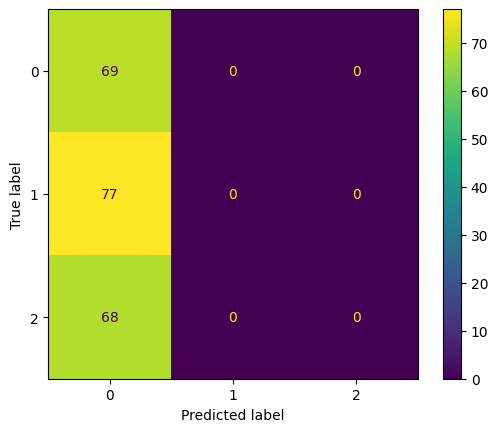

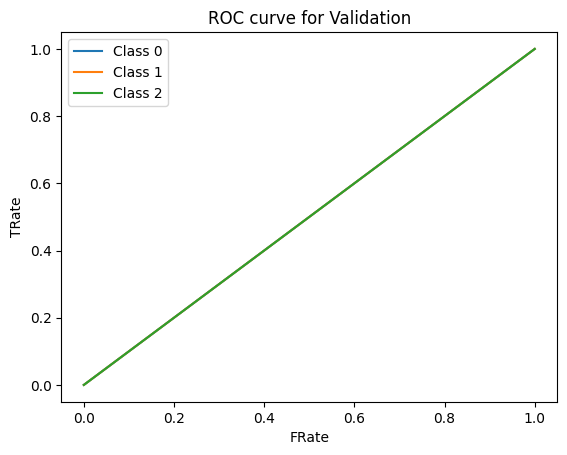


AUC Validation Metric:  0.5


In [18]:
####@@@-- Validation -- ###@@@

dimenrednd1 = Dimen_Reductm.time()
dimenrdcpr_probs = Dimenredmd.predict_proba(DimenRedctXavl)
dimenrdcpr = Dimenredmd.predict(DimenRedctXavl)
print(Dimen_Reductrpt(DimenRedctYavl, dimenrdcpr))
dimenrednd2 = Dimen_Reductm.time()
print("\nValidate Time--LR Classifier :", dimenrednd2 - dimenrednd1, "\n")

dimenreductcnx = Dimen_Reductcnmx(DimenRedctYavl, dimenrdcpr)
Dimen_Reductcnmxdp(confusion_matrix=dimenreductcnx, display_labels=[0, 1, 2]).plot()
Dimen_ReductMn.show()

DimenRedctYavl_bin = Dimen_Reductlb(DimenRedctYavl, classes=Dimenredmd.classes_)
dimenrdcpr_bin = Dimen_Reductlb(dimenrdcpr, classes=Dimenredmd.classes_)
n_classes = DimenRedctYavl_bin.shape[1]

for i in range(n_classes):
    fp, tp, thres = Dimen_Reductmcs.roc_curve(DimenRedctYavl_bin[:, i], dimenrdcpr_probs[:, i])
    Dimen_ReductMn.plot(fp, tp, label=f'Class {Dimenredmd.classes_[i]}')

Dimen_ReductMn.xlabel('FRate')
Dimen_ReductMn.ylabel('TRate')
Dimen_ReductMn.title('ROC curve for Validation')
Dimen_ReductMn.legend(loc="best")
Dimen_ReductMn.show()

DimenRedtAuc = Dimen_Reductmcs.roc_auc_score(DimenRedctYavl, dimenrdcpr_probs, multi_class='ovr', average='macro')
print("\nAUC Validation Metric: ", DimenRedtAuc)

              precision    recall  f1-score   support

           0       0.30      1.00      0.47        65
           1       0.00      0.00      0.00        82
           2       0.00      0.00      0.00        67

    accuracy                           0.30       214
   macro avg       0.10      0.33      0.16       214
weighted avg       0.09      0.30      0.14       214


Test Time--LR Classifier : 0.03348350524902344 



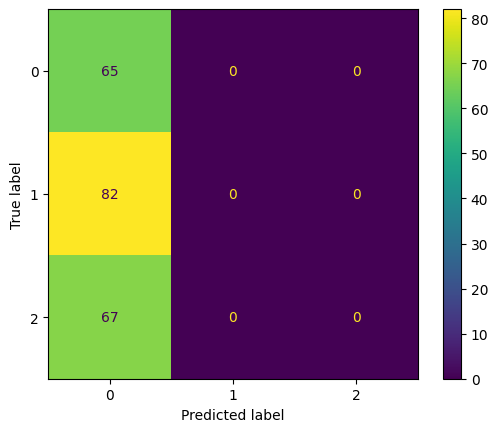

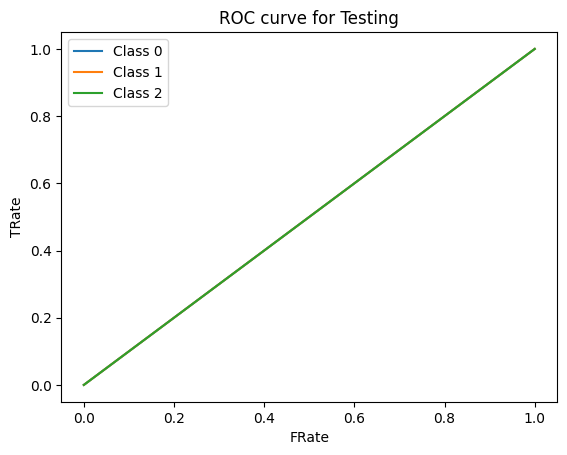


AUC Testing Metric:  0.5


In [19]:
####@@@-- Testing -- ###@@@

dimenrednd1 = Dimen_Reductm.time()
dimenrdcpr_probs = Dimenredmd.predict_proba(DimenRedctXatst)
dimenrdcpr = Dimenredmd.predict(DimenRedctXatst)
print(Dimen_Reductrpt(DimenRedctYatst, dimenrdcpr))
dimenrednd2 = Dimen_Reductm.time()
print("\nTest Time--LR Classifier :", dimenrednd2 - dimenrednd1, "\n")

dimenreductcnx = Dimen_Reductcnmx(DimenRedctYatst, dimenrdcpr)
Dimen_Reductcnmxdp(confusion_matrix=dimenreductcnx, display_labels=[0, 1, 2]).plot()
Dimen_ReductMn.show()

DimenRedctYatst_bin = Dimen_Reductlb(DimenRedctYatst, classes=Dimenredmd.classes_)
dimenrdcpr_bin = Dimen_Reductlb(dimenrdcpr, classes=Dimenredmd.classes_)
n_classes = DimenRedctYatst_bin.shape[1]

for i in range(n_classes):
    fp, tp, thres = Dimen_Reductmcs.roc_curve(DimenRedctYatst_bin[:, i], dimenrdcpr_probs[:, i])
    Dimen_ReductMn.plot(fp, tp, label=f'Class {Dimenredmd.classes_[i]}')

Dimen_ReductMn.xlabel('FRate')
Dimen_ReductMn.ylabel('TRate')
Dimen_ReductMn.title('ROC curve for Testing')
Dimen_ReductMn.legend(loc="best")
Dimen_ReductMn.show()


DimenRedtAuc = Dimen_Reductmcs.roc_auc_score(DimenRedctYatst, dimenrdcpr_probs, multi_class='ovr', average='macro')
print("\nAUC Testing Metric: ", DimenRedtAuc)

#Decision Tree Classifier

In [20]:
from sklearn.tree import DecisionTreeClassifier as Dimen_ReductDTC

Dimen_Reducthyprms = {
                       'criterion' : ['gini', 'entropy', 'log_loss'],
                       'splitter' : ['best', 'random'],
                       'max_depth' : [1, 5, 10, 50, None]
                       }

Dimenredmd = Dimen_ReductDTC()
Dimenredmd = Dimen_Reductgrdsh(Dimenredmd,Dimen_Reducthyprms, cv=2)
Dimenredmd.fit(DimenRedctXatrn[:5000], DimenRedctYatrn[:5000])
print("best Params -- DT:")
print(Dimenredmd.best_params_)

best Params -- DT:
{'criterion': 'gini', 'max_depth': 1, 'splitter': 'best'}


In [21]:
####@@@-- Training -- ###@@@

dimenrednd1 = Dimen_Reductm.time()
Dimenredmd = Dimen_ReductDTC(**Dimenredmd.best_params_)
Dimenredmd.fit(DimenRedctXatrn, DimenRedctYatrn)
dimenrednd2 = Dimen_Reductm.time()
print("\nTrain Time--DT classifier   :", dimenrednd2-dimenrednd1,"\n")


Train Time--DT classifier   : 0.007829427719116211 



              precision    recall  f1-score   support

           0       0.32      1.00      0.49        69
           1       0.00      0.00      0.00        77
           2       0.00      0.00      0.00        68

    accuracy                           0.32       214
   macro avg       0.11      0.33      0.16       214
weighted avg       0.10      0.32      0.16       214


Validate Time--DT Classifier : 0.030299663543701172 



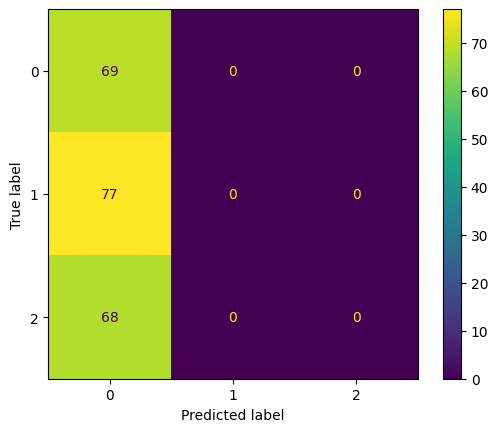

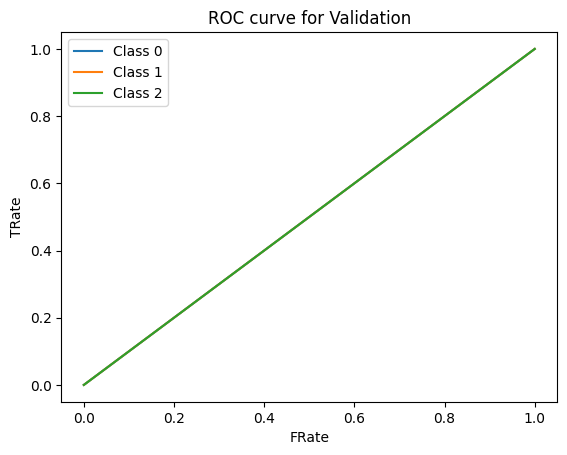


AUC Validation Metric:  0.5


In [22]:
####@@@-- Validation -- ###@@@

dimenrednd1 = Dimen_Reductm.time()
dimenrdcpr_probs = Dimenredmd.predict_proba(DimenRedctXavl)
dimenrdcpr = Dimenredmd.predict(DimenRedctXavl)
print(Dimen_Reductrpt(DimenRedctYavl, dimenrdcpr))
dimenrednd2 = Dimen_Reductm.time()
print("\nValidate Time--DT Classifier :", dimenrednd2 - dimenrednd1, "\n")

dimenreductcnx = Dimen_Reductcnmx(DimenRedctYavl, dimenrdcpr)
Dimen_Reductcnmxdp(confusion_matrix=dimenreductcnx, display_labels=[0, 1, 2]).plot()
Dimen_ReductMn.show()

DimenRedctYavl_bin = Dimen_Reductlb(DimenRedctYavl, classes=Dimenredmd.classes_)
dimenrdcpr_bin = Dimen_Reductlb(dimenrdcpr, classes=Dimenredmd.classes_)
n_classes = DimenRedctYavl_bin.shape[1]

for i in range(n_classes):
    fp, tp, thres = Dimen_Reductmcs.roc_curve(DimenRedctYavl_bin[:, i], dimenrdcpr_probs[:, i])
    Dimen_ReductMn.plot(fp, tp, label=f'Class {Dimenredmd.classes_[i]}')

Dimen_ReductMn.xlabel('FRate')
Dimen_ReductMn.ylabel('TRate')
Dimen_ReductMn.title('ROC curve for Validation')
Dimen_ReductMn.legend(loc="best")
Dimen_ReductMn.show()

DimenRedtAuc = Dimen_Reductmcs.roc_auc_score(DimenRedctYavl, dimenrdcpr_probs, multi_class='ovr', average='macro')
print("\nAUC Validation Metric: ", DimenRedtAuc)

              precision    recall  f1-score   support

           0       0.30      1.00      0.47        65
           1       0.00      0.00      0.00        82
           2       0.00      0.00      0.00        67

    accuracy                           0.30       214
   macro avg       0.10      0.33      0.16       214
weighted avg       0.09      0.30      0.14       214


Test Time--DT Classifier : 0.04415011405944824 



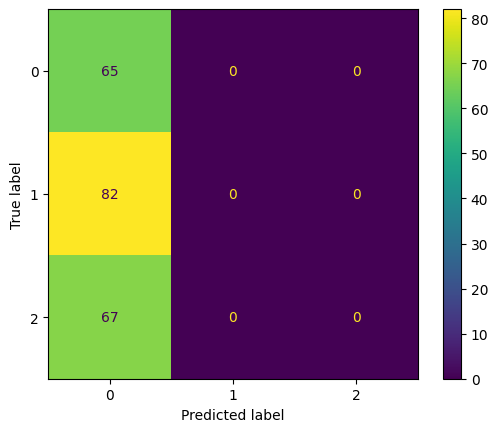

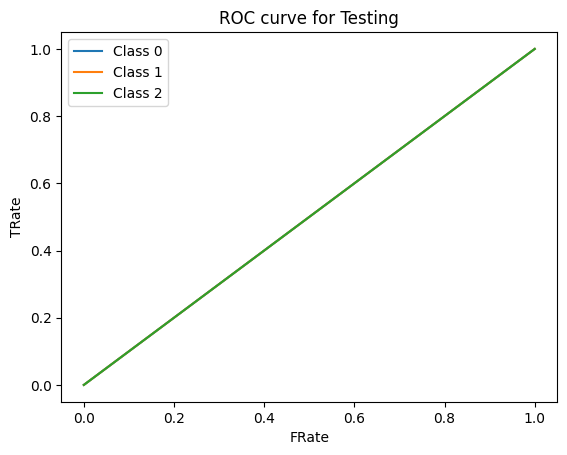


AUC Testing Metric:  0.5


In [23]:
####@@@-- Testing -- ###@@@

dimenrednd1 = Dimen_Reductm.time()
dimenrdcpr_probs = Dimenredmd.predict_proba(DimenRedctXatst)
dimenrdcpr = Dimenredmd.predict(DimenRedctXatst)
print(Dimen_Reductrpt(DimenRedctYatst, dimenrdcpr))
dimenrednd2 = Dimen_Reductm.time()
print("\nTest Time--DT Classifier :", dimenrednd2 - dimenrednd1, "\n")

dimenreductcnx = Dimen_Reductcnmx(DimenRedctYatst, dimenrdcpr)
Dimen_Reductcnmxdp(confusion_matrix=dimenreductcnx, display_labels=[0, 1, 2]).plot()
Dimen_ReductMn.show()


DimenRedctYatst_bin = Dimen_Reductlb(DimenRedctYatst, classes=Dimenredmd.classes_)
dimenrdcpr_bin = Dimen_Reductlb(dimenrdcpr, classes=Dimenredmd.classes_)
n_classes = DimenRedctYatst_bin.shape[1]


for i in range(n_classes):
    fp, tp, thres = Dimen_Reductmcs.roc_curve(DimenRedctYatst_bin[:, i], dimenrdcpr_probs[:, i])
    Dimen_ReductMn.plot(fp, tp, label=f'Class {Dimenredmd.classes_[i]}')

Dimen_ReductMn.xlabel('FRate')
Dimen_ReductMn.ylabel('TRate')
Dimen_ReductMn.title('ROC curve for Testing')
Dimen_ReductMn.legend(loc="best")
Dimen_ReductMn.show()


DimenRedtAuc = Dimen_Reductmcs.roc_auc_score(DimenRedctYatst, dimenrdcpr_probs, multi_class='ovr', average='macro')
print("\nAUC Testing Metric: ", DimenRedtAuc)

#Balanced Random Forest Classifier

In [24]:
from imblearn.ensemble import BalancedRandomForestClassifier as Dimen_ReductBRF


Dimen_Reducthyprms = {
                       'n_estimators' : [10, 50, 100, 200],
                       'criterion' : ['gini', 'entropy', 'log_loss'],
                       'max_depth' : [1, 5, 50, None],
                       'max_features': [None, 'sqrt', 'log2']
                       }

Dimenredmd = Dimen_ReductBRF()
Dimenredmd = Dimen_Reductgrdsh(Dimenredmd,Dimen_Reducthyprms, cv=2)
Dimenredmd.fit(DimenRedctXatrn[:5000], DimenRedctYatrn[:5000])
print("best Params -- BRF:")
print(Dimenredmd.best_params_)

best Params -- BRF:
{'criterion': 'gini', 'max_depth': 1, 'max_features': None, 'n_estimators': 100}


In [25]:
####@@@-- Training -- ###@@@

dimenrednd1 = Dimen_Reductm.time()
Dimenredmd = Dimen_ReductBRF(**Dimenredmd.best_params_)
Dimenredmd.fit(DimenRedctXatrn, DimenRedctYatrn)
dimenrednd2 = Dimen_Reductm.time()
print("\nTrain Time--BRF classifier   :", dimenrednd2-dimenrednd1,"\n")


Train Time--BRF classifier   : 0.30442166328430176 



              precision    recall  f1-score   support

           0       0.32      1.00      0.49        69
           1       0.00      0.00      0.00        77
           2       0.00      0.00      0.00        68

    accuracy                           0.32       214
   macro avg       0.11      0.33      0.16       214
weighted avg       0.10      0.32      0.16       214


Validate Time--BRF Classifier : 0.024264097213745117 



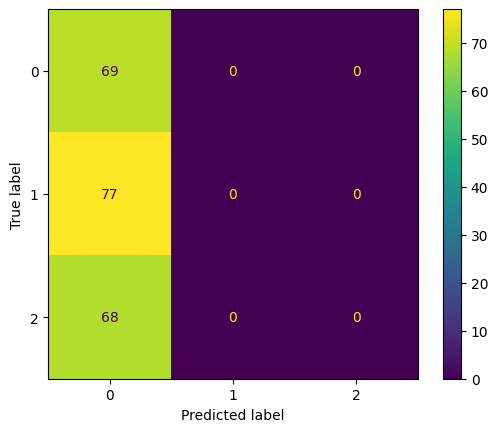

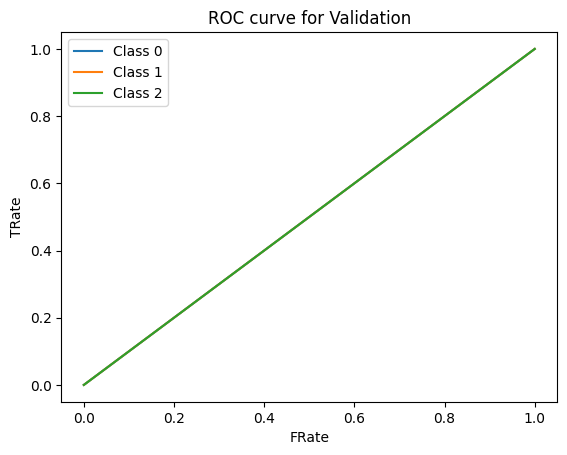


AUC Validation Metric:  0.5


In [26]:
####@@@-- Validation -- ###@@@

dimenrednd1 = Dimen_Reductm.time()
dimenrdcpr_probs = Dimenredmd.predict_proba(DimenRedctXavl)
dimenrdcpr = Dimenredmd.predict(DimenRedctXavl)
print(Dimen_Reductrpt(DimenRedctYavl, dimenrdcpr))
dimenrednd2 = Dimen_Reductm.time()
print("\nValidate Time--BRF Classifier :", dimenrednd2 - dimenrednd1, "\n")

dimenreductcnx = Dimen_Reductcnmx(DimenRedctYavl, dimenrdcpr)
Dimen_Reductcnmxdp(confusion_matrix=dimenreductcnx, display_labels=[0, 1, 2]).plot()
Dimen_ReductMn.show()


DimenRedctYavl_bin = Dimen_Reductlb(DimenRedctYavl, classes=Dimenredmd.classes_)
dimenrdcpr_bin = Dimen_Reductlb(dimenrdcpr, classes=Dimenredmd.classes_)
n_classes = DimenRedctYavl_bin.shape[1]


for i in range(n_classes):
    fp, tp, thres = Dimen_Reductmcs.roc_curve(DimenRedctYavl_bin[:, i], dimenrdcpr_probs[:, i])
    Dimen_ReductMn.plot(fp, tp, label=f'Class {Dimenredmd.classes_[i]}')

Dimen_ReductMn.xlabel('FRate')
Dimen_ReductMn.ylabel('TRate')
Dimen_ReductMn.title('ROC curve for Validation')
Dimen_ReductMn.legend(loc="best")
Dimen_ReductMn.show()

DimenRedtAuc = Dimen_Reductmcs.roc_auc_score(DimenRedctYavl, dimenrdcpr_probs, multi_class='ovr', average='macro')
print("\nAUC Validation Metric: ", DimenRedtAuc)

              precision    recall  f1-score   support

           0       0.30      1.00      0.47        65
           1       0.00      0.00      0.00        82
           2       0.00      0.00      0.00        67

    accuracy                           0.30       214
   macro avg       0.10      0.33      0.16       214
weighted avg       0.09      0.30      0.14       214


Test Time--BRF Classifier : 0.016869783401489258 



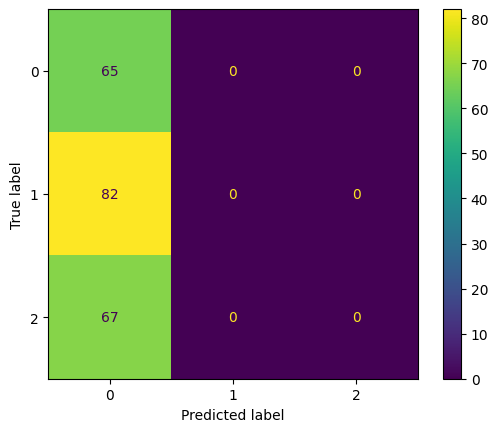

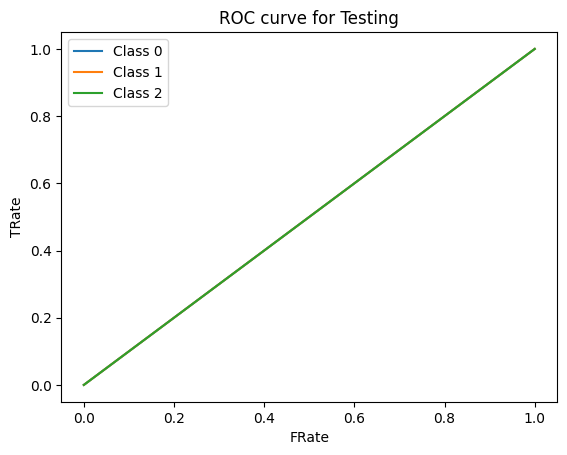


AUC Testing Metric:  0.5


In [27]:
####@@@-- Testing -- ###@@@

dimenrednd1 = Dimen_Reductm.time()
dimenrdcpr_probs = Dimenredmd.predict_proba(DimenRedctXatst)
dimenrdcpr = Dimenredmd.predict(DimenRedctXatst)
print(Dimen_Reductrpt(DimenRedctYatst, dimenrdcpr))
dimenrednd2 = Dimen_Reductm.time()
print("\nTest Time--BRF Classifier :", dimenrednd2 - dimenrednd1, "\n")

dimenreductcnx = Dimen_Reductcnmx(DimenRedctYatst, dimenrdcpr)
Dimen_Reductcnmxdp(confusion_matrix=dimenreductcnx, display_labels=[0, 1, 2]).plot()
Dimen_ReductMn.show()


DimenRedctYatst_bin = Dimen_Reductlb(DimenRedctYatst, classes=Dimenredmd.classes_)
dimenrdcpr_bin = Dimen_Reductlb(dimenrdcpr, classes=Dimenredmd.classes_)
n_classes = DimenRedctYatst_bin.shape[1]

for i in range(n_classes):
    fp, tp, thres = Dimen_Reductmcs.roc_curve(DimenRedctYatst_bin[:, i], dimenrdcpr_probs[:, i])
    Dimen_ReductMn.plot(fp, tp, label=f'Class {Dimenredmd.classes_[i]}')

Dimen_ReductMn.xlabel('FRate')
Dimen_ReductMn.ylabel('TRate')
Dimen_ReductMn.title('ROC curve for Testing')
Dimen_ReductMn.legend(loc="best")
Dimen_ReductMn.show()


DimenRedtAuc = Dimen_Reductmcs.roc_auc_score(DimenRedctYatst, dimenrdcpr_probs, multi_class='ovr', average='macro')
print("\nAUC Testing Metric: ", DimenRedtAuc)